# Introducción

Obtener información sobre el proceso de recolección de datos resulta fundamental para entender nuestra base y poder tomar decisiones justificadas a la hora de la limpieza y curación de la misma. A continuación se comparte un fragmento de la metodología aplicada para la recolección de datos, la cual tiene por objetivo brindar mayor información sobre la base trabajada.

### **Descripción del proceso de recolección de datos**

La recolección de los tweets se realizó a través de un proceso de scrapping, utilizando la libreria [twscrape](https://github.com/vladkens/twscrape). Para la búsqueda de tweets, se utilizó un filtro de palabras claves relacionadas a obesidad. La recolección de datos tuvo lugar entre enero de 2024 y diciembre de 2024, de forma ininterrumpida. Así, se obtuvo una muestra de 11111 tweets. La recolección se llevó a cabo con un script que utiliza el lenguaje de programación Python, el cual permitió almacenar los datos en MongoDB, una base de datos no relacional. Este trabajo utilizó recursos computacionales del Centro de Cómputos de Alto Desempeño (CCAD) de la Universidad Nacional de Córdoba (https://ccad.unc.edu.ar/), que forman parte del Sistema Nacional de Computación de Alto Desempeño del MinCyT de la República Argentina.

#### Selección de palabras clave

Para poder identificar aquellos tweets que correspondían a la temática de obesidad se utilizaron palabras clave como filtro de búsqueda. Este filtro al momento de ser utilizado (año 2024) no permite el uso de expresiones regulares (las cuales permiten considerar patrones para hacer coincidir secuencias de caracteres). Dada esta situación, y asumiendo que existen diversas formas coloquiales de escribir en esta red social que pueden contener errores de ortografía, de tipeo, entre otros, se tomó la decisión de sistematizar el proceso de selección de palabras clave para que el mismo sea objetivo y se pierda la menor cantidad de información posible. Además, se consideró que existen otras palabras que son utilizadas por los usuarios/as de Twitter para referirse a la obesidad, justificando la búsqueda de posibles sinónimos. En un comienzo se identificaron las palabras consideradas “semilla”, es decir aquellas que servirían como precursoras del resto de las palabras. Las palabras semilla consideradas fueron las distintas flexiones de la palabra obesidad: “obesidad”, “obeso”, “obesa”, “obesos” y “obesas”. Para reconocer otras palabras claves que estuvieran relacionadas a la temática y que pueden ser utilizadas en el mismo contexto se empleó la técnica de Word Embedding (WE). El WE es una técnica de PLN que utiliza distintos métodos para representar las palabras de un texto mediante vectores de números reales. Las palabras se ubican en el espacio vectorial de acuerdo con la relación y similitud semántica que guardan entre ellas. La distancia entre las mismas se denomina índice de similitud de coseno, el cual mientras más cercano a 1, mayor será la similitud entre las palabras observadas. El WE utilizado fue entrenado previamente con un corpus de tweets de Argentina por investigadores de la Facultad de Matemática, Astronomía, Física y Computación – FaMAF (Peréz y Luque, 2019). Se identificaron aquellas 50 palabras que presentaron un mayor índice de similitud del coseno por cada palabra semilla mencionada. Luego, se seleccionaron como palabras claves sólo aquellas que cumplieran con un criterio de sinonimia, es decir, que puedan ser utilizadas en reemplazo de la palabra semilla y dado el mismo contexto no perdieran el significado semántico. Así, finalmente se obtuvieron un total de 21 palabras clave:          
       
*'Obesidad', 'obesidaddd', 'gordura', 'sobrepeso', 'gorduras', 'adiposidad', 'Sobrepeso', 'obesito', 'obesoo', 'obesidad', 'obeso', 'obesa', 'gorrrdura', 'obesaa', 'obesita', 'Obesa', 'obesaaa', 'Obesos', 'Obesas', 'obesas', 'obesos'.*

### **Problemas interesantes a abordar**

¿Cuáles son los principales temas de conversación sobre obesidad en Twitter?
¿Existen diferencias en el contenido compartido según la provincia? ¿Y según el mes?
¿Cómo varía el nivel de interacción (likes, retweets, respuestas) según el tipo de contenido del tweet?
¿Se pueden detectar períodos de mayor actividad relacionados con eventos específicos?
¿La cantidad de palabras que se utilizan en el tweet se asocia a un sentimiento negativo o positivo, o es indistinto?

### **Descripción del dataset**
Este repositorio contiene una base de datos con 11111 registros y 13 columnas recopilados de Twitter a partir de palabras clave sobre obesidad. La información fue extraída con el objetivo de analizar conversaciones en torno a la obesidad en Argentina, incluyendo interacciones, fechas, hashtags y datos geográficos. Para identificar la provincia de origen de los usuarios que generaron los tweets, se realizó un proceso de reconocimiento de localidades, ciudades y departamentos más relevantes y frecuentes a partir de la variable "location" asociada a cada usuario. Posteriormente, se asignó una provincia a cada tweet con base en esa información. En los casos en que un tweet presenta dos o más provincias identificadas, esto se debe a que el usuario mencionó múltiples lugares en su descripción de ubicación. Esta variable se denominó "pcia".

Más información disponible [aquí](https://github.com/eugehaluszka/mentoria_2025/tree/main/datasets).

## **Práctico 1**

En esta primera etapa, se trabajará con el dataset de tweets sobre obesidad para realizar un análisis exploratorio inicial. El objetivo es identificar patrones generales en los datos mediante visualizaciones: distribución de tweets por provincia o mes, volumen de interacciones (likes, retweets, respuestas), y posibles tendencias en la conversación pública. También se podrán contemplar la cantidad de palabras utilizadas en cada tweet, así como los términos más utilizados entre otros análisis descriptivos.
Se espera que este práctico permita conocer mejor la estructura de los datos y generar preguntas o hipótesis para análisis posteriores.

### **Cargando el dataset**

In [1]:
#Importar librerias de interes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import zipfile
%matplotlib inline

In [2]:
#Descargar la base desde el github

!wget -O base_obesidad_completa.zip "https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip"
with zipfile.ZipFile("base_obesidad_completa.zip", "r") as z:
    z.extractall()

--2025-08-09 18:13:28--  https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip [following]
--2025-08-09 18:13:28--  https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1043853 (1019K) [application/zip]
Saving to: ‘base_obesidad_completa.zip’

base_obesidad_compl 100%[===================>]   1019K  --.-KB/s    in 0.07

In [3]:
#Abrir la base de datos
df = pd.read_csv("base_obesidad_completa.csv", encoding="utf-8-sig")
df_original = df.copy() #se genera copia
df.head(3)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id
0,1747300752475730129,2024-01-16 16:52:17,Boluda ahí dice que yo debería pesar 43kg eso ...,1,0,1.0,0,1747290800474476846,[],18.0,['argentina'],1,0
1,1747297783743197385,2024-01-16 16:40:29,"Jugador de +30 años, vendehumo, con tendencias...",0,0,1.0,0,1747268216882102581,[],21.0,['buenos aires'],1,1
2,1747295025363341318,2024-01-16 16:29:31,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI ...",0,0,0.0,0,1747295025363341318,[],54.0,['buenos aires'],1,2


### Procesamiento y curación del dataset, para su posterior aplicación de machine learning

Al finalizar este práctico 2 obtendrán una base de datos lista para usar en el práctico 3. Es por eso que deben entregar la notebook con las resoluciones y la base de datos alojada en un repositorio (puede ser el mismo de la mentoria, me pasan sus usuarios y les doy permiso a editar el repo), o alojada en un repositorio de uds mismos.

### **Limpieza de la base de datos**

#### Ejercicio 1.
A partir de la información brindada sobre el proceso de recolección y construcción de la base de datos se propone:

- a. Eliminar de la base aquellos tweets que, según lo trabajado en el Práctico 1, fueron considerados como irrelevantes para el análisis de esta temática o que podrían generar ruido en las interpretaciones. Este proceso es fundamental para ambos grupos e implica una serie de pasos cíclicos o repetitivos, hasta que la base de datos esté lista para el análisis. Por ello, en este ejercicio se espera que desarrollen y describan el proceso de limpieza de la base de manera detallada, fundamentando adecuadamente cada una de las decisiones tomadas.
- b. Eliminar tweets duplicados (realizar este punto si no lo hicieron con anterioridad)
- c. Ejecutar nuevamente al menos tres de los gráficos descriptivos vistos en el práctico 1, que el grupo considere más relevantes, con el objetivo de observar si la distribución de las variables se ha visto significativamente modificada a partir de los cambios realizados en la base de datos. Se pueden incluir más gráficos si así lo desean.


#### Ejercicio 1 a)

Primero revisemos algunos comentarios, los que solo tienen una palabra, o los que no tienen ninguna de las palabras listadas como keywords.

In [4]:
# Número de comentarios con una sola palabra
one_word_comments = df['rawContent'].str.split().apply(len) == 1
num_one_word_comments = one_word_comments.sum()
print(f"Número de comentarios con solo una palabra: {num_one_word_comments}")
df[one_word_comments].rawContent.value_counts().sort_values(ascending=False).tail(10)

Número de comentarios con solo una palabra: 91


,count
rawContent,
Obesidad,2
VAMOOOOOOOSSSSSSSSSSS,1
💙💛,1
maravilloso,1
concuerdo,1
😧🤣,1
Obesas,1
Sobrepeso*,1
godrencia,1


In [5]:
# Número de comentarios con una sola palabra
two_word_comments = df['rawContent'].str.split().apply(len) == 2
num_two_word_comments = two_word_comments.sum()
print(f"Número de comentarios con dos palabras: {num_two_word_comments}")
df[two_word_comments].rawContent.value_counts().sort_values(ascending=False).head(25)

Número de comentarios con dos palabras: 120


,count
rawContent,
gordo obeso,3
obeso link_url,2
? link_url,2
La obesidad,2
alto obeso,1
obeso incogible,1
la amo,1
callate obesa,1
con sobrepeso,1


In [6]:
# Número de comentarios con menos de n palabras y que contienen 'link_url'
less_than_n_words_and_link = (df['rawContent'].str.split().apply(len) < 4) & (df['rawContent'].str.contains('link_url', na=False))
num_less_than_n_words_and_link = less_than_n_words_and_link.sum()
print(f"Número de comentarios con menos de 4 palabras y un enlace: {num_less_than_n_words_and_link}")
df[less_than_n_words_and_link].rawContent.value_counts().sort_values(ascending=False).to_frame()

Número de comentarios con menos de 4 palabras y un enlace: 78


,count
rawContent,
link_url,46
? link_url,2
obeso link_url,2
QUÉ link_url,1
playtime! link_url,1
NEYMAR ?????? link_url,1
invítenme😍 link_url,1
🫣 link_url,1
#Medinazo link_url,1


In [7]:
import re

keywords = ['Obesidad', 'obesidaddd', 'gordura', 'sobrepeso', 'gorduras', 'adiposidad', 'Sobrepeso', 'obesito',
            'obesoo', 'obesidad', 'obeso', 'obesa', 'gorrrdura', 'obesaa', 'obesita', 'Obesa', 'obesaaa', 'Obesos',
            'Obesas', 'obesas', 'obesos', 'gordo', 'gorda', 'gordos', 'gordas', 'peso', 'pesar']

pattern = '|'.join(keywords)
df['containKeyword'] = df['rawContent'].str.contains(pattern, flags=re.IGNORECASE, na=False)

In [8]:
pd.set_option('display.max_colwidth', None)
df[~df['containKeyword']].rawContent

,rawContent
2,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI FAVOR✨ 🪬GRACIAS, GRACIAS, GRACIAS🫂"
3,"Me puse una cartera usada que me regalaron y tenía $500 adentro olvidados. Tenía que venir al taller re cargada y no tenía efectivo más que eso, me pedí un auto y no entiendo cómo pero salió $472 un día de lluvia. \nBuen día que placer esta pavada link_url"
8,QUÉ link_url
16,y nosotros qué culpa tenemos retrasada mental?
17,"En Rosario pagamos $240 desde el año pasado y tenemos que subsidiarle el boleto a Micaela para que viaje por unos MISERABLES $92 y encima SE QUEJA, ¿entienden por qué se odia tanto a los porteños en el interior?"
...,...
11098,"sé que hay peores pero bueno, dejo la pendorcha que tengo como árbol que mi gato se empeña en destrozar (lo está consiguiendo) link_url"
11102,"""Venimos de la premisa de que todo es gratis, y nada es gratis. Como dice un gran economista, Milton FREEDOM...""\n\nEl nivel de las diputadas de LLA para justificar que le saquen el medicamento de la hipertensión a un jubilado, mamita link_url"
11106,"no, no estoy bien chicos, pasenme plata al cbu porque me bajó la presión"
11109,esto aplica a todo el mundo menos a vos hija de re mil puta a mi sí me traumaste y sólo te deseo bendiciones porque para desgracias ya tenes suficiente con tu personalidad ojala te mejores como persona


En el trabajo anterior y aquí de nuevo hemos observado comentarios tanto irrelevantes como que generan ruido:
- Comentarios en inglés que no tienen que ver con la temática o solo de manera adyacente y difícil de capturar en cualquier análisis que realicemos.
- Comentarios de una sola palabra, encontramos 46 con "link_url", que no aportan información relevante. Por otro lado, como lo que vamos a realizar es un análisis de las distintas temáticas en torno a la obesidad en Twitter comentarios con una palabra no aportan suficiente información como para ser agrupado en relación de los temas ya detectados o posibles temas que surgan en el análisis. La principal diferencia es que no queda claro si se trata de insultos, lo que si sucede al considerar dos palabras.
- En las keywords hemos agregado algunas palabras hacia el final, pero aún con estas encontramos 2000 comentarios que no tienen ninguna de ellas en el contenido. Lo más seguro es que la palabra haya estado en otro lado, en el nombre de usuario, un usuario mencionado, el link ya borrado o alguna otra parte del tweet.
- Algunos de los comentarios con mayor cantidad de interacciones no tienen que ver con la temática. Si la limpieza previa aún deja comentarios irrelevantes entre los que tienen más interacciones, los revisaremos manualmente dado la importancia que revisten para un análisis donde consideremos los comentarios más interactuados.

In [9]:
%%capture
!pip install langid

In [10]:
import langid
df['idioma'] = df['rawContent'].apply(lambda x: langid.classify(x)[0])

In [11]:
df.idioma.value_counts().head()

,count
idioma,
es,10237
en,264
pt,98
gl,78
an,68


In [ ]:
# Nos quedamos con los tweets en español
cleaned_df = df[df['idioma'] == 'es'].copy()
print(f"Se eliminarion {len(df) - len(cleaned_df)} tweets")

Se eliminarion 874 tweets


In [ ]:
# Filtramos aquellos tweets que no contienen palabras clave
rows = cleaned_df.shape[0]
cleaned_df = cleaned_df[cleaned_df['containKeyword']]
print(f"Se eliminarion {rows - len(cleaned_df)} tweets")

Se eliminarion 1659 tweets


In [ ]:
# Eliminamos comentarios de una sola palabra
one_word_comments = cleaned_df['rawContent'].str.split().apply(len) == 1
rows = cleaned_df.shape[0]
cleaned_df = cleaned_df[~one_word_comments]
print(f"Se eliminarion {rows - len(cleaned_df)} tweets")

Se eliminarion 24 tweets


In [ ]:
less_than_n_words_and_link = (cleaned_df['rawContent'].str.split().apply(len) < 4) & (cleaned_df['rawContent'].str.contains('link_url', na=False))
rows = cleaned_df.shape[0]
cleaned_df = cleaned_df[~less_than_n_words_and_link]
print(f"Se eliminarion {rows - len(cleaned_df)} tweets")

Se eliminarion 4 tweets


In [ ]:
cleaned_df.shape

(8550, 15)

Revisaremos los comentarios con mayor cantidad de interacciones

In [ ]:
cleaned_df.sort_values(by='retweetCount', ascending=False)[['rawContent', 'retweetCount']].head(10)

,rawContent,retweetCount
7744,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE",40546
9630,"Como de podrido por dentro tienes que estar para ser guardia civil, encontrarte un camión cargado hasta arriba de material de ayuda para Valencia y pararlo para pesarlo y multar a los voluntarios por superar la carga máxima",17520
7362,"Barbara Butch es la judía, obesa, lesbiana y queer que representó a Jesús de forma insultante en la ceremonia de los JJOO de 2024 del viernes.\n\nLos patrocinadores ya han comenzado a retirarse tras la actuación que insultó a miles de millones de cristianos. link_url",9395
9888,"""Cuando una sociedad pierde su brújula moral, se derrumba desde dentro"". – G.K. Chesterton\n\nUn hilo que expone la decadencia de Occidente🧵\n\n1. La celebración de la obesidad link_url",7610
9767,Detrás de toda mujer trabajadora hay un gato gordo que se queda durmiendo en la cama,7284
6492,se burlan de una señora grande que creció sin educación y esas son sus creencias pero acá tenés a pablalunar que te dice que color de tanga usar para que te den leche esta semana y tenes a las gordas aplaudiendo con el papo,6811
9934,los chabones cuando pesas mas de 50 kilos: che puede q seas un poco obesa mórbida no?,6021
9263,"«Cuando una sociedad pierde su brújula moral, se derrumba desde dentro». – G. K. Chesterton\n\nUn hilo que expone la decadencia de Occidente 🧵\n\n1. La celebración de la obesidad link_url",5932
6378,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,5877
1418,"la ""gordura"" es comun en gente con menos acceso a comida buena porque comen harinas y comida barata. el 70% de termos stanley en este pais es trucho. si no estudiaron economia por lo menos estudien nutricion qsyyy",4607


In [ ]:
cleaned_df.sort_values(by='replyCount', ascending=False)[['rawContent', 'replyCount']].head(10)

,rawContent,replyCount
5772,"Nelly Furtado subió esta foto y en cualquier momento la borra 😬\nSe le llenó de comentarios de mujeres llamándola ""gorda"" y que debería darle vergüenza vestirse así. link_url",10753
7362,"Barbara Butch es la judía, obesa, lesbiana y queer que representó a Jesús de forma insultante en la ceremonia de los JJOO de 2024 del viernes.\n\nLos patrocinadores ya han comenzado a retirarse tras la actuación que insultó a miles de millones de cristianos. link_url",7352
7744,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE",6332
4846,"Cada vez que en el gimnasio veo una persona obesa haciendo aparatos me dan ganas de decirle anda a correr a la cinta!!! Baja de peso! Hace aeróbico y después aparatos no te sirve gord@ eso! \n\nPero como tengo que ser políticamente correcta, lo digo en twitter.",2587
1276,"Toda la tarde fui tendencia en esta red por “ gorda” , la verdad me voy a preocupar cuando discutan mis ideas, para mí las mujeres somos todas lindas, no tengo problemas de autoestima.\nLo de los ascensores lo plantee en el marco de que los diputados y diputadas tenemos libre circulación dentro de la cámara , pero entiendo que laburan de esto .\nTal vez era más fácil hablar de mi cuerpo que de un copito en el congreso.\nLos dejo, me voy a descansar , estuvimos trabajando hasta hace un rato con la ley ómnibus o combi a esta altura para ser más exactos, mañana tal vez aparezca el dictamen, eso es lo urgente.",2503
6096,"Playa en 1970.\nNo hay obesidad, no habian drogadictos, no existian tatuajes, ni implantes de plástico. No hay camas playeras porque tumbarse en la arena desestresa, no hay sombrillas porque el Sol en buena medida fortalece la salud, ni hay gafas de sol ni cremas tóxicas. No hay móviles sino gente real hablando en una red social original y sobre todo no hay lineas blancas en el cielo. \nNo hay nada, pero hay de todo. Hay que volver a lo que funciona, y lo que funciona no es nada de lo estamos haciendo hoy. Hay que rebelarse!",2440
8498,"Ayer tuve un evento y me presentaron a un chico. 37 años, yo cuarenta. “ es muy buena persona”. Lo es. \nProblema. Yo no puedo salir con una persona que con 37 años tiene sobrepeso, fuma y se bebe hasta el agua de los floreros. Por no decir lo que come.",2297
6378,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,1768
9900,nunca verás a una chica de gym con un obeso,1524
7535,gorda de mierda no comas tanto y listo link_url,1513


In [ ]:
cleaned_df.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'containKeyword', 'idioma'],
      dtype='object')

In [ ]:
cleaned_df.sort_values(by='likeCount', ascending=False)[['rawContent', 'likeCount']].head(10)

,rawContent,likeCount
7744,"Cómplices, por acción u omisión.\n\nEn Venezuela hay una Dictadura Comunista que secuestra, tortura y asesina a cualquiera que se les oponga. Ninguna persona honesta intelectualmente puede negar esta realidad.\n\n¿No les llama la atención que todos los políticos, periodistas, empresarios y sindicalistas que nos tildaron de fascistas cierren la boca con respecto a la dictadura venezolana?\n\nIncluso algunos apoyan al Dictador Maduro. Dicen, sin ponerse colorados, que ganó las elecciones de forma legítima. Que Venezuela es una democracia. Todo esto mientras afirman que nuestro movimiento es fascista.\n\nEl Comunismo es una ideología asesina y antihumana que siempre termina en una dictadura sangrienta y asesina, como el fascismo.\n\nNunca vas a escuchar a los periodistas progresistas y bienpensantes decir que el comunismo es una ideología asesina. Es hora que elijan y salgan de la neutralidad. A los imbéciles de la idea del centrismo bienpensante y que tildan de fascista a todo aquel que escapa de su lógica mediocre les pregunto de modo directo:\n¿Maduro o Corina Machado?\n\nMientras sigan buscando al helado caliente, al esqueleto obeso y a la meretriz virgen seguirán siendo los grandes cómplices del desastre decadente argentino.\nVLLC !!!\n\nPD: lindo brete para los boluprogres del centrismo bienpensate, ya que si eligen se contradicen con todo lo que han venido diciendo/escribiendo (en su definición se vuelven fascistas) y si se mantienen nuestros dejan bien en claro la basura que son.\nJAQUE MATE",140507.0
9934,los chabones cuando pesas mas de 50 kilos: che puede q seas un poco obesa mórbida no?,97604.0
9875,Chicos perdón pero soy gorda y la mitad de los tipos que me hablan son como ese (no tan gigantes pero todos gymbros),82216.0
6378,Porque los hombres gordos son graciosos y las mujeres gordas son insoportables???,75306.0
9622,nunca voy a entender xq se auto percibe león si es una hiena con sobrepeso,73103.0
6492,se burlan de una señora grande que creció sin educación y esas son sus creencias pero acá tenés a pablalunar que te dice que color de tanga usar para que te den leche esta semana y tenes a las gordas aplaudiendo con el papo,72315.0
9888,"""Cuando una sociedad pierde su brújula moral, se derrumba desde dentro"". – G.K. Chesterton\n\nUn hilo que expone la decadencia de Occidente🧵\n\n1. La celebración de la obesidad link_url",65926.0
9900,nunca verás a una chica de gym con un obeso,65593.0
10641,"Llevo al perro a la veterinaria después de mucho tiempo y me dice: ese animal está gordo. Ofendido y dispuesto a pelear le digo que es la raza (como si no supiera), que son músculos. Me contesta: ahí tenés una balanza, pesalo. 5 kilos arriba está este sindicalista hijo de puta. link_url",65418.0
9682,la nutricionista me dijo q si tenía mucho antojo de boludeces que vea videos de gente obesa comiendo jaksksjs ????,62001.0


In [ ]:
delete_list = [7744, 9630, 9767]
cleaned_df = cleaned_df[~cleaned_df.index.isin(delete_list)]

#### Ejercicio 1 b)

In [ ]:
cantidad_duplicados = cleaned_df.duplicated(subset=['rawContent']).sum()
cleaned_df = cleaned_df.drop_duplicates(subset=['rawContent'])

print(f"Cantidad de duplicados eliminados en la columna 'rawContent': {cantidad_duplicados}")

Cantidad de duplicados eliminados en la columna 'rawContent': 60


#### Ejercicio 1 c)

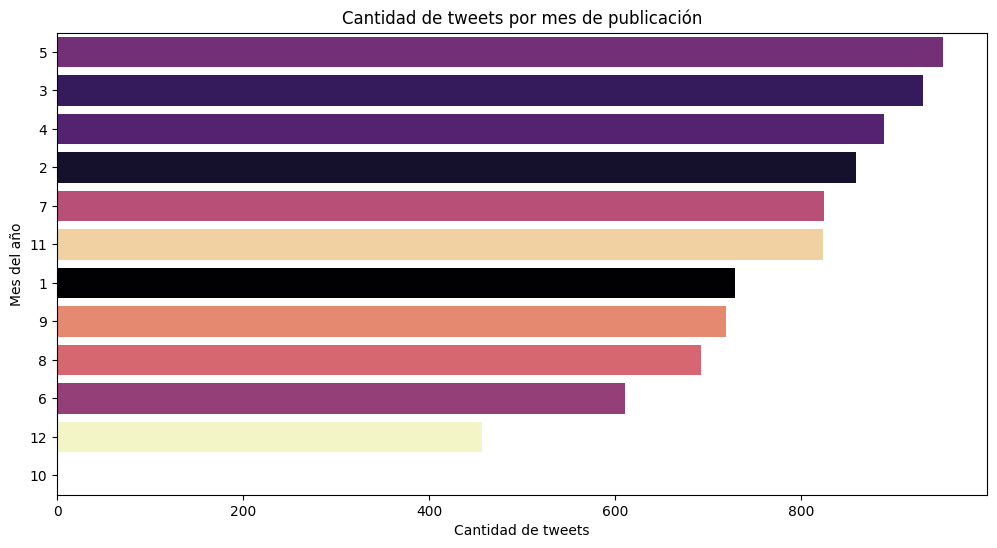

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_df, y='mes', order=cleaned_df['mes'].value_counts().index, palette='magma', hue='mes', legend=False)
plt.xlabel('Cantidad de tweets')
plt.ylabel('Mes del año')
plt.title('Cantidad de tweets por mes de publicación')
plt.show()

En el caso de los meses el orden de de la distribución cambió.

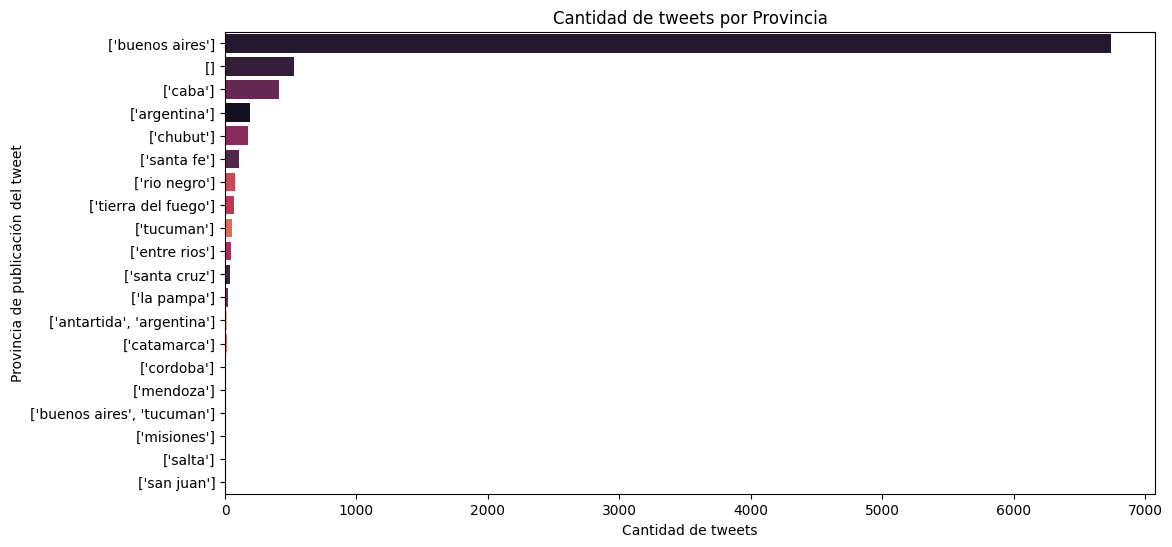

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_df, y='pcia', order=cleaned_df['pcia'].value_counts().index, palette='rocket', hue='pcia', legend=False)
plt.xlabel('Cantidad de tweets')
plt.ylabel('Provincia de publicación del tweet')
plt.title('Cantidad de tweets por Provincia')
plt.show()

In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)
cleaned_df['viewCount'].describe()

,viewCount
count,"8,432.00"
mean,"19,641.15"
std,"290,457.44"
min,1.00
25%,13.00
50%,41.00
75%,137.00
max,"11,744,987.00"


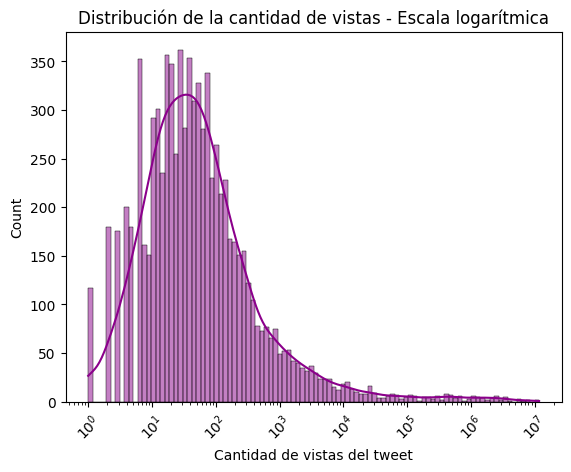

In [ ]:
sns.histplot(cleaned_df['viewCount'], color='darkmagenta', kde=True, bins=100, log_scale=True)
plt.xticks(rotation=45)
plt.xlabel('Cantidad de vistas del tweet')
plt.title('Distribución de la cantidad de vistas - Escala logarítmica')

plt.show()

### **Limpieza del cuerpo de texto**

#### Ejercicio 2

Para analizar el contenido de tipo texto es importante eliminar todo el ruido que puede dificultar la interpretación del mismo. En este punto será importante conocer sobre expresiones regulares y cómo funcionan. Pueden probar en [regexr](https://regexr.com/) o en [regex101](https://regex101.com/)

- a. Se deberá generar una nueva columna en la base que considere el cuerpo de texto "limpio". Para ello deberán eliminar del cuerpo de texto todo lo que consideran como ruido para su análisis posterior, justificando el por qué pueden considerarlo ruido o no.
Usualmente se suelen eliminar símbolos o caracteres extraños, enlaces, nombres de usuarios, **emojis**, hashtags, entre otros. ¿Ustedes que decisiones tomarían?


#### Ejercicio 2 a)

In [ ]:
cleaned_df.rawContent[50:80]

,rawContent
69,"Con la técnica, el volumen y la intensidad correcta, estos ejercicios incluso pueden ayudar a mejorar problemas como:\n- Diabetes\n- Insulinoresistencia \n- Artitris \n- Hipertension\n- Obesidad \n- Osteosporosis \nEntre otros"
70,A ustedes ya da lástima hasta contestarles e insultarlos...las larvas y las cucarachas tienen más dignidad que un chavestia muerto del hambre defendiendo a una caterva de narcos obesos y millonarios que se les burlan en la cara.. que cosa inútil para la sociedad son en un todo.
71,Bolívar por Cabanillas es lo aplaudible 👏🏼👏🏼👏🏼\nSe le nota el sobrepeso y un poco apático
72,no había sanciones por gordura? le chorrea la grasa amigo link_url
74,lloran los trolos las chetas naranjas y los obesos que van a la tribuna y no cierran el orto hoy gano la gente de bien
76,como q se queda el puto obeso este lpm
78,Seguro le corta la circulación de la gordura
80,La gente obesa mira los rombos en el etiquetado de los alimentos como los fumadores la foto del canceroso en la marquilla.
81,"¡Qué riquísimas son las vacaciones!\nDesayunar como un rey, almorzar como un rey y cenar como un rey.\nGordura monarca absolutista."
82,"Ayer en mi barrio se agarraron 3 contra 1. El solitario sangraba y en el trío había una mina. Todos con sobrepeso, todos con palos. Qué les pasa? #santelmo"


- Eliminar "link_url"
- Caracteres random como alsbskbdksjdid o ajdhksbdksjs
- Reemplazar los jdjsjs, o jsjsj o jajja o cualquier otra variante por "jaja"
- Eliminar repeticiones de signos de puntuación exceptuando los 3 puntos
- Eliminar letras al final repetidas más de una vez, como en ayy dioss
- Transformar emojis a texto (español)
- Dejar los hashtags puesto que hay muchos que contienen información útil para clasificarlos temáticamente, como los de gran hermano

In [ ]:
%%capture
!pip install emoji

In [ ]:
import emoji

# Contadores para cada tipo de normalización
counters = {
    'link_url_removed': 0,
    'gibberish_removed': 0,
    'laughter_standardized': 0,
    'punctuation_normalized': 0,
    'repeated_chars_normalized': 0,
    'emojis_converted': 0
}

def remove_link_url(text: str) -> tuple[str, int]:
    clean_text, modifications = re.subn(r'\blink_url\b', '', text, flags=re.IGNORECASE)
    if modifications > 0:
        counters['link_url_removed'] += 1
    return clean_text, modifications

def remove_gibberish(text: str) -> tuple[str, int]:
    # Nota: Se usa una lista completa de consonantes para mayor precisión.
    consonants = "bcdfghjklmnpqrstvwxyz"
    # El patrón busca cualquier palabra (\w*) que contenga 4 o más consonantes seguidas.
    pattern = rf'\b\w*[{consonants}]{{4,}}\w*\b'

    clean_text, modifications = re.subn(pattern, '', text, flags=re.IGNORECASE)
    if modifications > 0:
        counters['gibberish_removed'] += 1
    return clean_text, modifications

def standardize_laughter(text: str) -> tuple[str, int]:
    # Busca patrones como jajaja, jeje, jsjsj, hahaha, etc. y los reemplaza por 'jaja'
    # Patrón 1: Risas con vocales (jaja, jeje, jajjjjaa, etc.)
    # Requiere al menos dos "sílabas" de risa. Una sílaba es (consonante/s)(vocal/es).
    pattern1 = r'([jh]+[aeiou]+([jh]+[aeiou]+)+)'
    # Patrón 2: Risas basadas solo en 'j' y 's' (jsjsjs, jsjssjj, etc.)
    # Requiere al menos 4 caracteres para evitar falsos positivos.
    pattern2 = r'([js]{4,})'

    # Unimos los patrones con un OR (|) dentro de un límite de palabra (\b)
    laughter_pattern = re.compile(rf'\b({pattern1}|{pattern2})\b', re.IGNORECASE)

    clean_text, modifications = laughter_pattern.subn('jaja', text)
    if modifications > 0:
        counters['laughter_standardized'] += 1
    return clean_text, modifications

def normalize_punctuation(text: str) -> tuple[str, int]:
    # Protege los puntos suspensivos para no eliminarlos
    text_protected = text.replace('...', '__ELLIPSIS__')
    # Elimina cualquier otro signo de puntuación repetido (ej. !!, ??)
    clean_text, modifications = re.subn(r'([.,!?;:])\1+', r'\1', text_protected)
    # Restaura los puntos suspensivos
    clean_text = clean_text.replace('__ELLIPSIS__', '...')

    if modifications > 0 or '__ELLIPSIS__' in text_protected:
        counters['punctuation_normalized'] += 1
        return clean_text, 1
    return clean_text, 0

def normalize_repeated_chars(text: str) -> tuple[str, int]:
    # Reduce secuencias de la misma letra a solo una (ej. holaaa -> hola, gool -> gol)
    clean_text, modifications = re.subn(r'([a-zA-Z])\1{2,}', r'\1', text, flags=re.IGNORECASE)
    if modifications > 0:
        counters['repeated_chars_normalized'] += 1
    return clean_text, modifications

def demojize_text(text: str) -> tuple[str, int]:
    original_text = text
    clean_text = emoji.demojize(text, language='es')
    if original_text != clean_text:
        counters['emojis_converted'] += 1
        return clean_text, 1
    return clean_text, 0

# Lista de funciones a aplicar en orden
cleaning_functions = [
    remove_link_url,
    remove_gibberish,
    standardize_laughter,
    normalize_punctuation,
    normalize_repeated_chars,
    demojize_text
]

def clean_pipeline(text: str) -> str:
    for func in cleaning_functions:
        text, _ = func(text)
    return text.strip()

cleaned_df['cleanContent'] = cleaned_df['rawContent'].apply(clean_pipeline)

print("### Conteo de Modificaciones ###")
pd.Series(counters)

### Conteo de Modificaciones ###


,0
link_url_removed,1089
gibberish_removed,284
laughter_standardized,372
punctuation_normalized,921
repeated_chars_normalized,151
emojis_converted,942


In [ ]:
cleaned_df.cleanContent[5000:5020]

,cleanContent
6679,El corazón... lo obeso que es... parece una pintura :cara_llorando_fuerte::cara_llorando_fuerte::cara_llorando_fuerte::cara_llorando_fuerte:
6680,Como le crecio el. pecho con ka gordura \nPara' con el flan
6681,Obeso esta bien?
6682,"Nací para disfrutar del buen comer, dios que alma obesa"
6683,#MesaCentral Cariola sería buena candidata: nada de fea y tendencia a la gordura
6684,"No se cual será el caso de la señora, pero la obesidad si es una enfermedad, la comida es una adicción como cualquier otra y también en muchos casos requiere de ayuda psicológica, yo no creo que una persona es obesa por elección o por gusto."
6685,como soy la gorda más gorda me traje una porción en la cartera y quedó así:
6686,yo hace dos minutos viendo las fotos que me sacaron: no que gorda de re mierda alto asco dios \n\nyo ahora comiendo un rogel: DAME DOS MÁS
6688,"No pensas en que está tratando de ayudarla? Quizás fue un poco duro. Pero todo empieza desde una buena alimentación, tener una microbiota saludable. la obesidad trae consigo enfermedades crónicas y sufrimiento. Es"
6697,hoy se duerme de a dos yo y mi gato obeso


### Creación y transformación de variables

Para conocer en mayor profundidad el conjunto de datos de texto (corpus) con el que estamos trabajando, es importante aplicar diversas técnicas básicas de procesamiento del lenguaje natural (NLP), las cuales pueden aportar información valiosa. En el Práctico 1, identificar las palabras más frecuentes resultó útil; sin embargo, muchas otras palabras que describen con mayor precisión el contenido de las publicaciones pueden tener baja frecuencia o pasar desapercibidas en un análisis superficial.

Por esta razón, es habitual aplicar técnicas como la lematización, que permiten unificar distintas formas flexionadas de una misma palabra (por ejemplo, singular/plural o masculino/femenino), facilitando una representación más coherente del contenido textual.

Además, al aplicar el análisis gramatical propio del NLP, podemos reconocer las categorías gramaticales presentes en los textos, como sustantivos, adjetivos y verbos, entre otras. Esto puede enriquecer la comprensión del corpus y abrir nuevas posibilidades de análisis.

A partir de estas ideas, se proponen los siguientes ejercicios:

#### Ejercicio 3: **Exploración básica con NLP**

- a. Usar una librería de procesamiento de lenguaje natural que sea compatible con corpus en español para procesar el texto de los tweets. Deberán generar una nueva variable en la base de datos que contenga únicamente los términos pertenecientes a una categoría gramatical de su elección. Por ejemplo: una columna llamada "sustantivos", que incluya todos los sustantivos reconocidos en cada tweet.

  Es importante seleccionar y justificar:  la librería utilizada, y el modelo de lenguaje elegido (por ejemplo, es_core_news_sm en spaCy).

*Deberán decidir si aplican el procesamiento NLP sobre el texto limpio o sobre el texto crudo del tweet, y explicar las razones de esa elección.*

- b. Aplicar lematización a los términos reconocidos en la categoría gramatical seleccionada, generando una nueva variable con los términos lematizados. Observar y comparar los términos más frecuentes en esta categoría, tanto en su forma lematizada como sin lematizar. Finalmente, reflexionar sobre cuál de las dos representaciones elegirían para describir el dataset y justificar la elección.
- c. Discutir cómo podría aprovecharse esta información en tareas como análisis de sentimientos, detección de tópicos o predicción de engagement.

#### Ejercicio 4: **Transformar variables**

- a. Identificar columnas que necesiten transformación para ser usadas en modelos de ML (por ejemplo, fechas, categorías, frecuencias absolutas, etc.). *En este punto se espera ver el uso de técnicas de transformación de datos en al menos dos variables. Esto debe realizarse más allá de si será la variable utilizada a futuro*
- b. Generar nuevas variables a partir de los aspectos mencionados en el práctico 1. Por ejemplo, sentimiento asociado a las publicaciones (análisis de sentimiento).
- c. Convertir variables categóricas en variables numéricas (por ejemplo, usando codificación one-hot o label encoding).


#### Ejercicio 3 a)

La librería Spacy provee una serie de modelos ya entrenados y pipelines que los utilizan. Al ejecutar `spacy.load("es_core_news_lg")` lo que hacemos es cargar el pipeline con los modelos que ya hemos descargado. En este caso los componentes del pipeline son: `['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']`. Cada uno de estos componentes que transforman el documento tiene utiliza los siguientes modelos:
- tok2vec: spacy.Tok2Vec.v2 (una red que crea los embeddings de palabras contextuales)
- morphologizer: spacy.Tagger.v2
- parser: spacy.TransitionBasedParser.v2
- attribute_ruler: (No model architecture)
- lemmatizer: (No model architecture)
- ner: spacy.TransitionBasedParser.v2

Por ejemplo, en el caso de Tok2Vec, la documentación de la arquitectura dice lo siguiente: "Construct a tok2vec model out of two subnetworks: one for embedding and one for encoding." Recomiendan revisar este [link](https://explosion.ai/blog/deep-learning-formula-nlp) en donde dice lo siguiente: "After embedding the text into a sequence of vectors, bidirectional RNNs are used to encode the vectors into a sentence matrix. The rows of this matrix can be understood as token vectors — they are sensitive to the sentential context of the token." El componente tok2vec funciona en dos pasos principales:
- Sub-red de Embedding (Embed): Su único trabajo es convertir cada token (palabra) en un vector numérico inicial. Este vector no tiene contexto de la frase; es como una ficha de diccionario para esa palabra. CharacterEmbed y MultiHashEmbed son ejemplos de arquitecturas para este paso.
- Sub-red de Encoding (Encode): Esta red toma la secuencia completa de vectores iniciales y los procesa para inyectarles el contexto. Analiza las palabras vecinas para modificar el vector de cada palabra. El resultado es el embedding contextual final. MaxoutWindowEncoder es la arquitectura que hace este trabajo.

(Al final las explicaciones sobre las arquitecturas mencionadas).

El paquete cargado "es_core_news_lg" utiliza modelos entrenados en textos escritos, en particular noticias. Elegir este modelo es una cuestión de facilidad en el uso y de que para tareas de reconocimienton de partes de la oración reportan un accuracy alto, aunque no dicen con qué dataset se evaluó esta tarea. Sin embargo, encontramos una diferencia de dominio de los datos, puesto que nuestros textos provienen de Twitter que suele tener una forma de escribir más coloquial que las noticias.

Por último, SpaCy usa [etiquetas universales](https://universaldependencies.org/u/pos/NOUN.html) (NOUN, VERB, ADJ, etc.) y provee también atributos morfológicos si se requiere análisis profundo.

Además de Spacy, probaremos con la librería pysentimiento que provee un modelo de transformers basado en la arquitectura RoBERTa, que ha sido entrenado con un corpus de tweets en español y a su vez afinado para resolver tareas de POS tagging.

Para el caso de Spacy aplicaremos el análsis sobre el texto limpio, con la esperanza de que las normalizaciones realizadas ayuden al reconocimiento de los sustantivos. En el caso de Robertuito utilizaremos el texto sin modificaciones ya que este modelo fue entrenado con texto de twitter, además nos interesa comparar los resultados y ver si hay diferencias significativas.

In [ ]:
!python -m spacy download es_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 2.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("es_core_news_lg")

In [ ]:
print(f"Pipeline components: {nlp.pipe_names}\n")

Pipeline components: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']



In [ ]:
print("Architectures per component:")
for component_name in nlp.pipe_names:
    # Acceder a la configuración de cada componente
    component_config = nlp.config["components"][component_name]

    # La arquitectura del modelo se encuentra en la sección "model"
    # La clave suele ser "@architectures"
    if "model" in component_config and component_config["model"] is not None and "@architectures" in component_config["model"]:
        architecture = component_config["model"]["@architectures"]
        print(f"- {component_name}: {architecture}")
    else:
        # Algunos componentes como 'attribute_ruler' no tienen un modelo de red neuronal
        print(f"- {component_name}: (No model architecture)")

Architectures per component:
- tok2vec: spacy.Tok2Vec.v2
- morphologizer: spacy.Tagger.v2
- parser: spacy.TransitionBasedParser.v2
- attribute_ruler: (No model architecture)
- lemmatizer: (No model architecture)
- ner: spacy.TransitionBasedParser.v2


In [ ]:
disabled_pipes = ["ner"]

# Listas para guardar todos los resultados
tokens_list = []
sents_list = []
nouns_list = []
verbs_list = []
adjectives_list = []
nouns_lemma_list = []

for doc in nlp.pipe(cleaned_df['cleanContent'], disable=disabled_pipes):
    # Extraer tokens y oraciones
    tokens_list.append([token.text for token in doc])
    sents_list.append([sent.text for sent in doc.sents])

    # Extraer POS y lemas (esto ya lo tenías)
    nouns_list.append([token.text for token in doc if token.pos_ == 'NOUN'])
    verbs_list.append([token.text for token in doc if token.pos_ == 'VERB'])
    adjectives_list.append([token.text for token in doc if token.pos_ == 'ADJ'])
    nouns_lemma_list.append([token.lemma_ for token in doc if token.pos_ == 'NOUN'])

# Asignar todas las listas a las nuevas columnas del DataFrame
cleaned_df['tokens'] = tokens_list
cleaned_df['sentences'] = sents_list
cleaned_df['spacy_lg_noun'] = nouns_list
cleaned_df['spacy_lg_verb'] = verbs_list
cleaned_df['spacy_lg_adjective'] = adjectives_list
cleaned_df['spacy_lg_noun_lemma'] = nouns_lemma_list

In [ ]:
cleaned_df.spacy_lg_noun.explode().value_counts().head(20)

,count
spacy_lg_noun,
obesidad,2281
sobrepeso,1502
gordura,687
obeso,476
gente,449
obesa,417
peso,377
años,332
persona,290


In [ ]:
cleaned_df.spacy_lg_verb.explode().value_counts().head(10)

,count
spacy_lg_verb,
tiene,696
tener,346
hace,318
tienen,282
hacer,255
tengo,250
comer,234
ver,229
dice,181


In [ ]:
cleaned_df.spacy_lg_adjective.explode().value_counts().head(10)

,count
spacy_lg_adjective,
obeso,1195
obesa,819
gorda,372
gordo,336
obesos,333
mórbida,216
obesas,152
mejor,150
bueno,120


In [ ]:
%%capture
!pip install pysentimiento

In [ ]:
from pysentimiento import create_analyzer
from pysentimiento.preprocessing import preprocess_tweet
pos_analyzer = create_analyzer(task="pos", lang="es")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
def safe_extract_nouns_robertuito(texto):
    """
    Procesa un texto con RoBERTuito POS tagging, aplicando preprocesamiento
    y manejo de errores. Devuelve una lista de sustantivos o [] si falla.
    """
    if not isinstance(texto, str) or texto.strip() == "":
        return []

    try:
        preprocessed = preprocess_tweet(texto)
        result = pos_analyzer.predict(preprocessed)

        if result.labels is None or result.tokens is None:
            return []

        # Filtra solo tokens etiquetados como NOUN
        return [
            token for token, label in zip(result.tokens, result.labels)
            if label == 'NOUN'
        ]

    except Exception as e:
        print(f"Error procesando texto: {texto[:100]}... -> {e}")
        return []

In [ ]:
make_prediction = True
if make_prediction:
  cleaned_df['robertuito_noun'] = cleaned_df['rawContent'].apply(safe_extract_nouns_robertuito)
  cleaned_df[['id_str', 'robertuito_noun']].to_csv("robertuito_noun.csv", index=False)
else:
  import ast
  nouns_df = pd.read_csv("robertuito_noun.csv")
  nouns_df['robertuito_noun'] = nouns_df['robertuito_noun'].apply(ast.literal_eval)
  cleaned_df = pd.merge(cleaned_df, nouns_df, on='id_str')

Error procesando texto: Y yo me mato haciéndole croquetitas de cualquier verdura y muffins de cualquier fruta… 🤦🏻‍♀️
Después... -> 'NoneType' object has no attribute 'startswith'
Error procesando texto: Ni siquiera contrataron a alguien con sobrepeso, eran todos cuerpos flacos 🤷🏻‍♀️... -> 'NoneType' object has no attribute 'startswith'
Error procesando texto: 🙏🙇‍♂️ Paola pide inclusión real

—Lo más difícil de vivir con obesidad es la vergüenza y el padecimi... -> 'NoneType' object has no attribute 'startswith'
Error procesando texto: ¿Tenés  sobrepeso u obesidad?

¿Cuántos años de tu vida le dedicaste a las dietas?

Bueno, ahora ima... -> 'NoneType' object has no attribute 'startswith'
Error procesando texto: Estamos siendo bastante benévolos en la elección de la analogía, ya que una simple fiebre se puede b... -> 'NoneType' object has no attribute 'startswith'
Error procesando texto: Les dejo algo que escribí respecto de lo que parece sentir, según mi experiencia, una persona con ob.

In [ ]:
cleaned_df['robertuito_noun'].explode().value_counts().head(20)

,count
robertuito_noun,
obesidad,2186
emoji,1652
sobrepeso,1488
link_url,1151
gordura,686
,647
gente,446
cara,423
peso,344


#### Ejercicio 3 b)

b. Aplicar lematización a los términos reconocidos en la categoría gramatical seleccionada, generando una nueva variable con los términos lematizados. Observar y comparar los términos más frecuentes en esta categoría, tanto en su forma lematizada como sin lematizar. Finalmente, reflexionar sobre cuál de las dos representaciones elegirían para describir el dataset y justificar la elección.
c. Discutir cómo podría aprovecharse esta información en tareas como análisis de sentimientos, detección de tópicos o predicción de engagement.

In [ ]:
cleaned_df[['spacy_lg_noun', 'spacy_lg_noun_lemma', 'robertuito_noun']].head(40)

,spacy_lg_noun,spacy_lg_noun_lemma,robertuito_noun
0,"[kg, orto, sobrepeso, peso, altura, peso]","[kg, orto, sobrepeso, peso, altura, peso]","[kg, orto, sobrepeso, peso, altura, peso]"
1,"[años, tendencias, sobrepeso, tribunero, boca]","[año, tendencia, sobrepeso, tribunero, boca]","[años, tendencias, sobrepeso, boca]"
4,"[tabla, pediatra, años]","[tabla, pediatra, año]","[tabla, pediatra, años]"
5,"[huevo, pesar, kg, lista]","[huevo, pesar, kg, lista]","[huevo, kg, lista, hadid]"
6,"[curiosidad, gente, kilos, veces, placer, comida, tiempo, plato, dedos]","[curiosidad, gente, kilo, veces, placer, comida, tiempo, plato, dedo]","[curiosidad, gente, kilos, veces, placer, comida, tiempo, plato, dedos]"
7,"[lista, sobrepeso]","[lista, sobrepeso]","[lista, sobrepeso]"
9,[cuadro],[cuadro],[cuadro]
10,"[azucar, fibra, minerales, MUERE, X]","[azucar, fibra, mineral, muere, x]","[dioss,,,es, azucar, fibra, minerales, OBESIDAD, BANANA, link_url]"
11,"[razón, médico, kg]","[razón, médico, kg]","[razón, médico, kg]"
12,"[calificandola, obesidad, persona, deciciones, hora, capacitada, deciciones, resto, argentinos, bolsa, sueldo]","[calificandola, obesidad, persona, decición, hora, capacitada, decición, resto, argentino, bolsa, sueldo]","[obesidad, persona, deciciones, hora, deciciones, resto, argentinos, bolsa, trigliceridos, sueldo]"


- Aunque en la mayoría de los casos hay coincidencias entre los sustantivos detectados por spacy y por robertuito, hay algunos comentarios en donde un modelo identifica palabras que otro no, como "banana" en el ejemplo 10 o "obesa" en el ejemplo 15
- Habría que revisar un poco más el tratamiento de los emojis, dado que a veces aparecen con todos los guiones bajos, podrían reemplazarse por palabras o eliminarse. Lo mismo habría que quitar los hashtags para este análisis.
- Robertuito nos dio problemas con algunos textos pero no terminamos de identificar el porqué.

#### Ejercicio 3 c)

Los sustantivos detectados en nuestro análisis aportan información semántica sobre el texto, dependiendo si la tarea lo requiere, utilizar las versiones lematizadas de estos sustantivos sería conveniente, esto nos permite considerar significados más generales, excluyendo algunas flexiones morfológicas dado que lematizar implica estandarizar, desambiguar, segmentar. Dado que el lema es la forma que por convenio se acepta como representante de todas las formas flexionadas de una misma palabra, permitirá que en el modelo desarrollado se capture el significado que aportan el grupo de palabras representados por el mismo lema. La utilidad o no de esto último dependerá del modelo que se esté utilizando, podemos encontrar casos en los cuales convenga utilizar las palabras sin lematizar. Por ejemplo, si utilizamos un LLM para realizar tareas de análisis de sentimiento, sería mejor dejar las flexiones de estas palabras puesto que pueden llegar a contener información relevante para la clasificación que nuestro modelo es capaz de manejar. Por otro lado, si se trata de realizar un regresión para la predicción de engagement, utilizar la lematización permitiría reducir un poco el ruido que generan las distintas flexiones; la lematización reduce la dimensionalidad del espacio de características. En modelos clásicos (como regresiones, TF-IDF, Bag-of-Words), tener "casa" y "casas" como dos características distintas diluye el poder predictivo.

#### Ejercicio 4 a)

Una de las variables a transformar para poder ser utilizada es la fecha, hay que tener en cuenta que la hora, el día de la semana o el mes del año son cíclicos (después de las 23 viene la 00, después de diciembre viene enero), y los modelos lineales no entienden esto. Una forma de manejar esta característica cíclica es usando las funciones seno y coseno. Es necesario utilizar ambas funciones, puesto que con una sola se pierde información, por ejemplo para las horas 0 y 12 tenemos que:
- $\sin(2\pi\cdot 0/24) = 0$
- $\sin(2\pi\cdot 12/24) = \sin(\pi) = 0$

Por lo tanto para poder distinguir estos momentos del día es necesario utilizar el coseno. Con el par (sin, cos) cada instante tiene una posición única en el círculo, y el modelo puede aprender relaciones continuas.

El objetivo de emplear las funciones seno y coseno es capturar la cercanía y sucesión de los valores (horas o días de la semana) al representarlos en un espacio circular, de modo que podamos modelar su naturaleza periódica. Por ello, proponemos tratar las variables hora y día de la semana de esta manera, y dejar la variable mes como categórica (dado que nuestros datos cubren un único año), aunque perdamos información de vecindad entre meses. En un escenario más amplio, convendría comparar estas opciones y evaluar empíricamente qué enfoque aporta más valor al modelo.


In [ ]:
cleaned_df['date'] = pd.to_datetime(cleaned_df['date'])

# 1. Extraer componentes básicos
cleaned_df['hora']   = cleaned_df['date'].dt.hour
cleaned_df['minuto'] = cleaned_df['date'].dt.minute
cleaned_df['segundo']= cleaned_df['date'].dt.second
cleaned_df['dia_semana'] = cleaned_df['date'].dt.dayofweek

cleaned_df['hora_decimal'] = (
    cleaned_df['hora'] +
    cleaned_df['minuto'] / 60 +
    cleaned_df['segundo'] / 3600
)

# 2. Codificación Cíclica
cleaned_df['hora_sin'] = np.sin(2 * np.pi * cleaned_df['hora_decimal']/24)
cleaned_df['hora_cos'] = np.cos(2 * np.pi * cleaned_df['hora_decimal']/24)

cleaned_df['dia_sin'] = np.sin(2 * np.pi * cleaned_df['dia_semana'] / 7)
cleaned_df['dia_cos'] = np.cos(2 * np.pi * cleaned_df['dia_semana'] / 7)

cleaned_df[['date', 'hora', 'hora_decimal', 'hora_cos','hora_cos', 'dia_semana', 'dia_sin', 'dia_cos']].head()

,date,hora,hora_decimal,hora_cos,hora_cos,dia_semana,dia_sin,dia_cos
0,2024-01-16 16:52:17,16,16.87,-0.29,-0.29,1,0.78,0.62
1,2024-01-16 16:40:29,16,16.67,-0.34,-0.34,1,0.78,0.62
4,2024-01-16 16:20:10,16,16.34,-0.42,-0.42,1,0.78,0.62
5,2024-01-16 00:01:36,0,0.03,1.00,1.00,1,0.78,0.62
6,2024-01-16 16:14:20,16,16.24,-0.44,-0.44,1,0.78,0.62


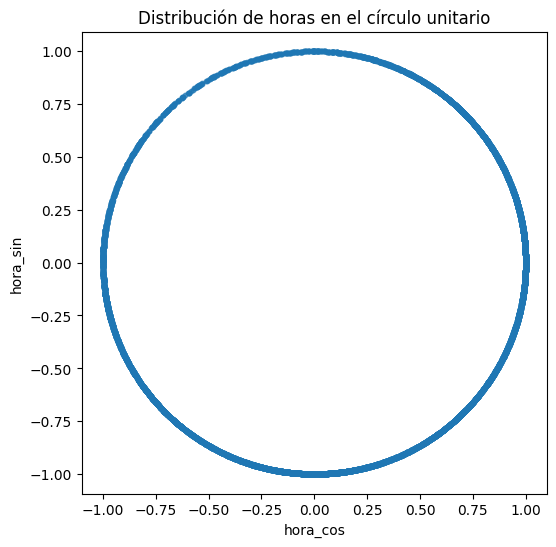

In [ ]:
plt.figure(figsize=(6,6))
# Dibujo del círculo unitario
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), lw=1, alpha=0.5)

# Puntos de tus datos
plt.scatter(cleaned_df['hora_cos'], cleaned_df['hora_sin'],
            s=10, alpha=0.7)

plt.axis('equal')
plt.xlabel('hora_cos')
plt.ylabel('hora_sin')
plt.title('Distribución de horas en el círculo unitario')
plt.show()

Como hemos visto, las varaibles replyCount, retweetCount, likeCount, viewCount tienen una distribución fuertemente asimétrica, una manera común de trabajar con ellas es aplicar una transformación logarítmica, log(x + 1) (el "+ 1" es para evitar el logaritmo de cero) comprime el rango de la variable, la hace más simétrica (parecida a una distribución normal) y reduce el impacto de los valores extremos.

Además podemos crear una nueva variable que represente la cantidad de likes por views (podríamos hacer lo mismoc on retweets y replies).

In [ ]:
# Lista de columnas a transformar
transform_cols = ['replyCount', 'retweetCount', 'likeCount', 'viewCount']

# Aplicar transformación logarítmica
for col in transform_cols:
    cleaned_df[f'{col}_log'] = np.log1p(cleaned_df[col])

# Crear tasa de likes (manejando divisiones por cero)
cleaned_df['tasa_like'] = cleaned_df['likeCount'] / (cleaned_df['viewCount'] + 1)

In [ ]:
cleaned_df.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'containKeyword', 'idioma', 'cleanContent',
       'spacy_lg_noun', 'spacy_lg_verb', 'spacy_lg_adjective',
       'spacy_lg_noun_lemma', 'robertuito_noun', 'hora', 'minuto', 'segundo',
       'dia_semana', 'hora_decimal', 'hora_sin', 'hora_cos', 'dia_sin',
       'dia_cos', 'pcia_unica', 'pcia_unica_buenos aires', 'pcia_unica_caba',
       'pcia_unica_catamarca', 'pcia_unica_chubut', 'pcia_unica_cordoba',
       'pcia_unica_entre rios', 'pcia_unica_la pampa', 'pcia_unica_mendoza',
       'pcia_unica_misiones', 'pcia_unica_rio negro', 'pcia_unica_salta',
       'pcia_unica_san juan', 'pcia_unica_santa cruz', 'pcia_unica_santa fe',
       'pcia_unica_tierra del fuego', 'pcia_unica_tucuman', 'replyCount_log',
       'retweetCount_log', 'likeCount_log', 'viewCount_log', 'tasa_like'],
      dtype='object')

In [ ]:
cleaned_df[['replyCount_log','retweetCount_log', 'likeCount_log', 'viewCount_log','tasa_like']]

,replyCount_log,retweetCount_log,likeCount_log,viewCount_log,tasa_like
0,0.69,0.00,0.69,2.94,0.05
1,0.00,0.00,0.69,3.09,0.05
4,0.00,0.00,0.00,4.60,0.00
5,5.82,7.50,10.40,13.50,0.05
6,0.00,0.00,0.00,2.94,0.00
...,...,...,...,...,...
11103,0.00,0.00,0.00,3.69,0.00
11104,0.00,0.00,0.69,4.39,0.01
11105,0.00,0.00,2.71,7.70,0.01
11107,0.00,0.00,0.69,2.40,0.09


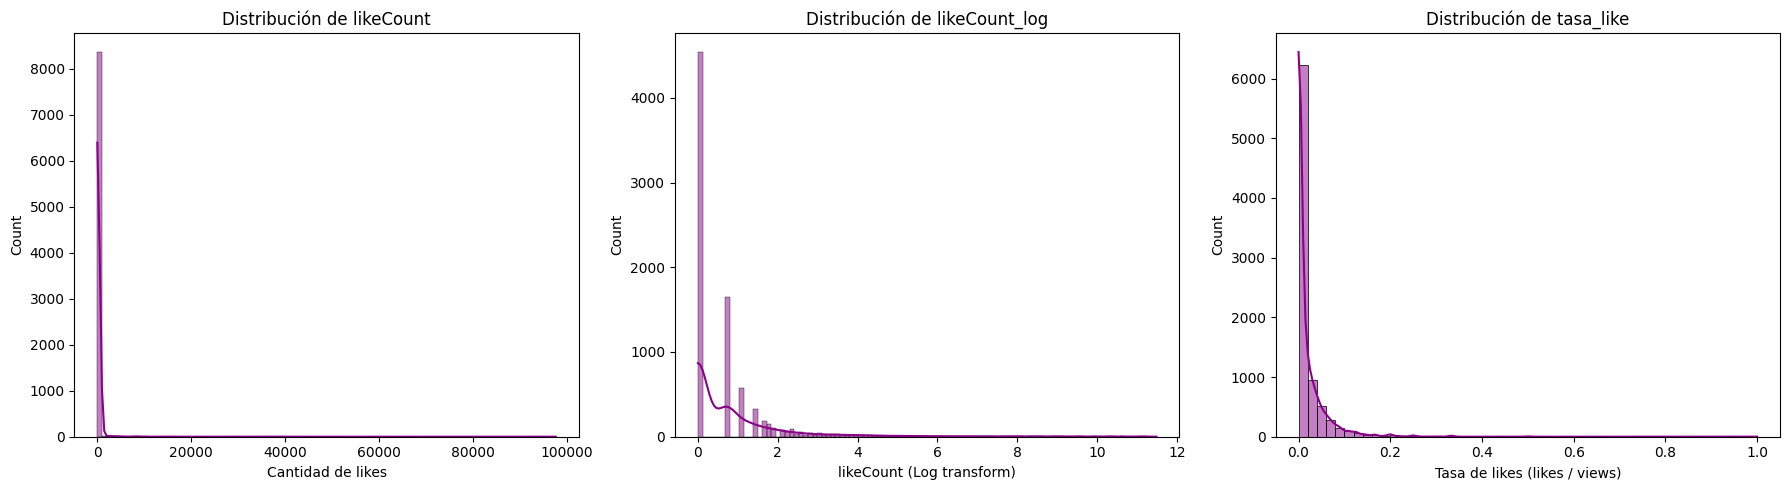

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(cleaned_df['likeCount'], ax=axes[0], color='darkmagenta', kde=True, bins=100)
axes[0].set_xlabel('Cantidad de likes')
axes[0].set_title('Distribución de likeCount')

sns.histplot(cleaned_df['likeCount_log'], ax=axes[1], color='darkmagenta', kde=True, bins=100)
axes[1].set_xlabel('likeCount (Log transform)')
axes[1].set_title('Distribución de likeCount_log')

sns.histplot(cleaned_df['tasa_like'], ax=axes[2], color='darkmagenta', kde=True, bins=50)
axes[2].set_xlabel('Tasa de likes (likes / views)')
axes[2].set_title('Distribución de tasa_like')

plt.tight_layout()
plt.show()

#### Ejercicio 4 b)

#### Ejercicio 4 c)

Podemos codificar la variable pcia con one-hot encodig dado que no tiene muchas categorías, el objetivo es convertir las categorías en números que un modelo de regresión pueda procesar. Creamos una nueva columna binaria (0 o 1) por cada categoría.

In [ ]:
cleaned_df.tail(20).columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'containKeyword', 'idioma', 'cleanContent',
       'spacy_lg_noun', 'spacy_lg_verb', 'spacy_lg_adjective',
       'spacy_lg_noun_lemma', 'robertuito_noun', 'hora', 'minuto', 'segundo',
       'dia_semana', 'hora_decimal', 'hora_sin', 'hora_cos', 'dia_sin',
       'dia_cos'],
      dtype='object')

In [ ]:
import ast

# codificar correctamente pcia como una lista
if type(cleaned_df['pcia'].iloc[0]) == str:
    cleaned_df['pcia'] = cleaned_df['pcia'].apply(ast.literal_eval)
cleaned_df['pcia'].explode().value_counts().head(20)

,count
pcia,
buenos aires,6740
caba,408
argentina,203
chubut,178
santa fe,105
rio negro,76
tierra del fuego,69
tucuman,54
entre rios,45


In [ ]:
borrar = {'argentina', 'antartida'}

def limpiar_pcia(lista):
    # Filtramos borrando los no deseados
    filtrada = [p for p in lista if p.lower() not in borrar]
    nombres = [p.lower() for p in filtrada]
    if 'buenos aires' in nombres and 'tucuman' in nombres:
        filtrada = [p for p in filtrada if p.lower() != 'tucuman']
    return filtrada
cleaned_df['pcia'] = cleaned_df['pcia'].apply(limpiar_pcia)

In [ ]:
cleaned_df['pcia_unica'] = cleaned_df['pcia'].apply(lambda L: L[0] if len(L)==1 else np.nan)

In [ ]:
cleaned_df[['pcia', 'pcia_unica']]

,pcia,pcia_unica
0,[],NaN
1,[buenos aires],buenos aires
4,[buenos aires],buenos aires
5,[buenos aires],buenos aires
6,[buenos aires],buenos aires
...,...,...
11103,[buenos aires],buenos aires
11104,[buenos aires],buenos aires
11105,[buenos aires],buenos aires
11107,[buenos aires],buenos aires


In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Preparamos el encoder
ohe = OneHotEncoder(
    sparse_output=False,             # para devolver un array denso
    handle_unknown='ignore'   # ignora provincias nuevas en predict()
)

# Ajustamos solo sobre las no-nulas
mask = cleaned_df['pcia_unica'].notna()
vals = cleaned_df.loc[mask, ['pcia_unica']]

In [ ]:
# Fit‑transform y construimos DataFrame de dummies
ohe_arr = ohe.fit_transform(vals)
cols   = ohe.get_feature_names_out(['pcia_unica'])
df_ohe = pd.DataFrame(ohe_arr, columns=cols, index=vals.index)

In [ ]:
df_ohe

,pcia_unica_buenos aires,pcia_unica_caba,pcia_unica_catamarca,pcia_unica_chubut,pcia_unica_cordoba,pcia_unica_entre rios,pcia_unica_la pampa,pcia_unica_mendoza,pcia_unica_misiones,pcia_unica_rio negro,pcia_unica_salta,pcia_unica_san juan,pcia_unica_santa cruz,pcia_unica_santa fe,pcia_unica_tierra del fuego,pcia_unica_tucuman
1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11103,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
11104,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
11105,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
11107,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
cleaned_df = pd.concat([cleaned_df, df_ohe], axis=1)

In [ ]:
cleaned_df.columns

Index(['id_str', 'date', 'rawContent', 'replyCount', 'retweetCount',
       'likeCount', 'quoteCount', 'conversationId', 'hashtags', 'viewCount',
       'pcia', 'mes', 'user_id', 'containKeyword', 'idioma', 'cleanContent',
       'spacy_lg_noun', 'spacy_lg_verb', 'spacy_lg_adjective',
       'spacy_lg_noun_lemma', 'robertuito_noun', 'hora', 'minuto', 'segundo',
       'dia_semana', 'hora_decimal', 'hora_sin', 'hora_cos', 'dia_sin',
       'dia_cos', 'pcia_unica', 'pcia_unica_buenos aires', 'pcia_unica_caba',
       'pcia_unica_catamarca', 'pcia_unica_chubut', 'pcia_unica_cordoba',
       'pcia_unica_entre rios', 'pcia_unica_la pampa', 'pcia_unica_mendoza',
       'pcia_unica_misiones', 'pcia_unica_rio negro', 'pcia_unica_salta',
       'pcia_unica_san juan', 'pcia_unica_santa cruz', 'pcia_unica_santa fe',
       'pcia_unica_tierra del fuego', 'pcia_unica_tucuman'],
      dtype='object')

Para trabajar con el conversationId podemos utilizar frequency encoding. Realizar un target encoding nos parece que no es posible puesto que hay demasiadas categorías con 1 elemento, y sería dificíl llenar con la media de la variable objetivo en esos casos.

In [ ]:
freq = cleaned_df['conversationId'].value_counts()

cleaned_df['conversation_freq'] = cleaned_df['conversationId'].map(freq)

cleaned_df['conversation_freq_norm'] = (
    cleaned_df['conversation_freq'] / cleaned_df['conversation_freq'].max()
)

In [ ]:
cleaned_df[['conversationId', 'conversation_freq', 'conversation_freq_norm']]

,conversationId,conversation_freq,conversation_freq_norm
0,1747290800474476846,1,0.04
1,1747268216882102581,1,0.04
4,1747292672232931781,1,0.04
5,1747046404873175457,1,0.04
6,1746941101645132124,3,0.12
...,...,...,...
11103,1868708807502970986,6,0.24
11104,1868688519184699813,1,0.04
11105,1868708807502970986,6,0.24
11107,1868747084482200016,1,0.04


Para utilizar los hashtags y los tipos de palabras que analizamos podríamos realizar un conteo con el número de cada uno. Para el caso de los hashtags también podríamos crear una variable binaria (contiene hashtags o no), o seleccionar los más frecuentes y realizar un one hot encoding.

Además podemos calcular:
- Densidad léxica: Una métrica que distingue entre palabras con contenido léxico de las palabras funcionales, en nuestro caso utilizaremos una versión simplificada que no incluye los adverbios puesto que no los hemos detectado:
$$\text{Densidad léxica} = \frac{\text{nro. de palabras de contenido}}{\text{nro. total de palabras}}$$

- Riqueza léxica: Mide la diversidad del vocabulario, por ejemplo el Type-Token Ratio (TTR) es la métrica más común para la riqueza léxica. Mide la proporción de palabras únicas (types) respecto al total de palabras (tokens). Un TTR alto sugiere un vocabulario más variado.

- Conteo de signos de puntuación: La frecuencia de ciertos signos puede ser un indicador de la tonalidad del texto.

- Conteo de mayúsculas: Un alto número de palabras en mayúsculas puede ser señal de énfasis.

- Conteo de caracteres, palabras y oraciones

- Longitud promedio de palabra y oración

- Ratio sustantivos-verbos.

In [ ]:
import ast
cleaned_df['hashtags'] = cleaned_df['hashtags'].apply(ast.literal_eval)

In [ ]:
cleaned_df['n_nouns'] = cleaned_df['spacy_lg_noun'].apply(len)
cleaned_df['n_verbs'] = cleaned_df['spacy_lg_verb'].apply(len)
cleaned_df['n_adj'] = cleaned_df['spacy_lg_adjective'].apply(len)
cleaned_df['n_hashtags'] = cleaned_df['hashtags'].apply(len)

cleaned_df[['n_nouns', 'n_verbs', 'n_adj', 'n_hashtags']]

,n_nouns,n_verbs,n_adj,n_hashtags
0,6,8,1,0
1,5,3,1,0
4,3,2,1,0
5,4,3,0,0
6,9,6,2,0
...,...,...,...,...
11103,1,3,2,0
11104,6,0,2,0
11105,0,0,2,0
11107,5,2,1,0


In [ ]:
cleaned_df['ttr'] = cleaned_df['tokens'].apply(lambda x: len(set(x)) / (len(x) + 1e-6))

n_content_words = cleaned_df['n_nouns'] + cleaned_df['n_verbs'] + cleaned_df['n_adj']
n_total_words = cleaned_df['tokens'].apply(len)
cleaned_df['lexical_density'] = (n_content_words / (n_total_words + 1e-6))

cleaned_df[['ttr', 'lexical_density']]

,ttr,lexical_density
0,0.86,0.36
1,0.83,0.37
4,1.00,0.46
5,1.00,0.39
6,0.78,0.41
...,...,...
11103,0.95,0.27
11104,0.89,0.44
11105,0.89,0.22
11107,0.95,0.42


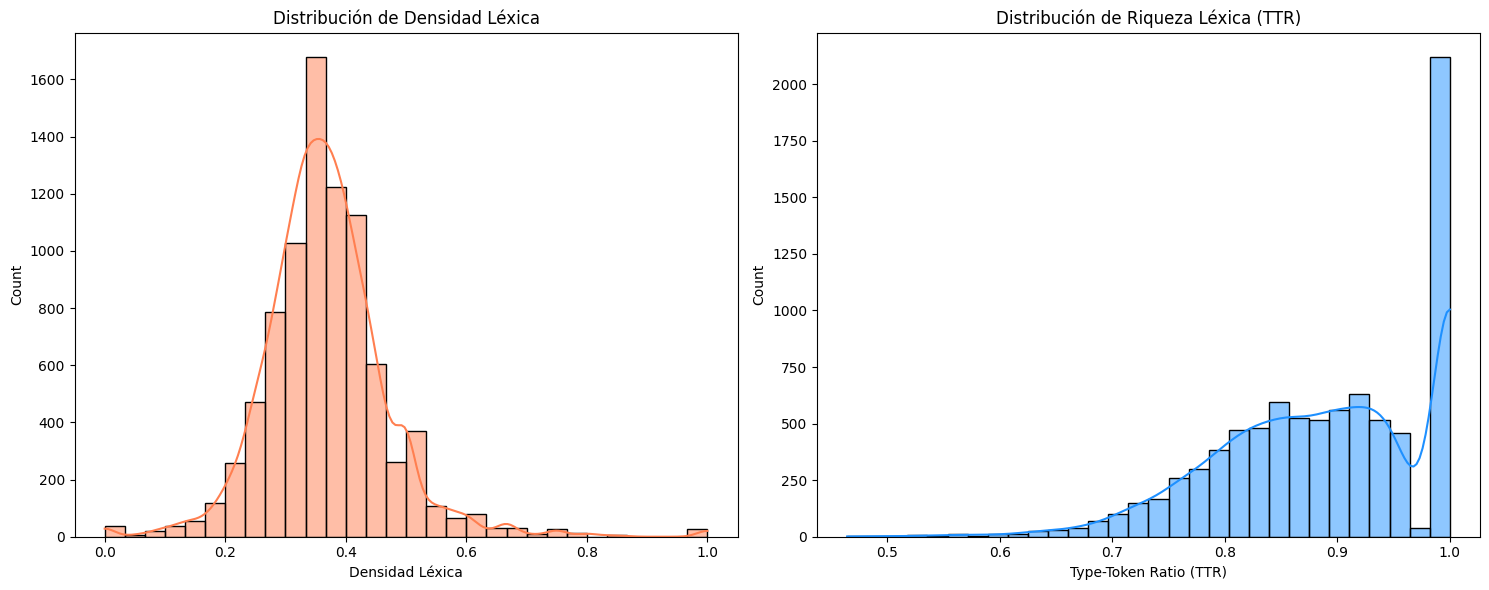

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting lexical_density on the left subplot
sns.histplot(cleaned_df['lexical_density'], ax=axes[0], color='coral', kde=True, bins=30)
axes[0].set_xlabel('Densidad Léxica')
axes[0].set_title('Distribución de Densidad Léxica')

# Plotting ttr on the right subplot
sns.histplot(cleaned_df['ttr'], ax=axes[1], color='dodgerblue', kde=True, bins=30)
axes[1].set_xlabel('Type-Token Ratio (TTR)')
axes[1].set_title('Distribución de Riqueza Léxica (TTR)')

plt.tight_layout()
plt.show()


In [ ]:
cleaned_df.ttr

,ttr
0,0.86
1,0.83
4,1.00
5,1.00
6,0.78
...,...
11103,0.95
11104,0.89
11105,0.89
11107,0.95


In [ ]:
cleaned_df[cleaned_df['ttr'] > 0.99][['rawContent', 'ttr', 'tokens']].head()

,rawContent,ttr,tokens
4,La tabla de mi pediatra cuando tenia 6 años y me decía obesa jsjs,1.00,"[La, tabla, de, mi, pediatra, cuando, tenia, 6, años, y, me, decía, obesa]"
5,chupame un huevo como voy a pesar 48 kg midiendo casi 1.70 quién hizo esta lista yolanda hadid,1.00,"[chupame, un, huevo, como, voy, a, pesar, 48, kg, midiendo, casi, 1.70, quién, hizo, esta, lista, yolanda, hadid]"
18,"Claro que sí, por la gordura pete!",1.00,"[Claro, que, sí, ,, por, la, gordura, pete, !]"
25,"lit, ojala se vuelvan obesas en serio ya q tanto lo quieren",1.00,"[lit, ,, ojala, se, vuelvan, obesas, en, serio, ya, q, tanto, lo, quieren]"
29,lo peor es q la mayoría en ese país comen así y enseñan eso con razón todos tienen obesidad mórbida,1.00,"[lo, peor, es, q, la, mayoría, en, ese, país, comen, así, y, enseñan, eso, con, razón, todos, tienen, obesidad, mórbida]"


In [ ]:
cleaned_df['n_sentences'] = cleaned_df['sentences'].apply(len)
cleaned_df['n_tokens'] = cleaned_df['tokens'].apply(len)

cleaned_df[['cleanContent', 'n_sentences', 'n_tokens']].head()

,cleanContent,n_sentences,n_tokens
0,"Boluda ahí dice que yo debería pesar 43kg eso está para el orto. Yo sé que tengo sobrepeso y por eso estoy empezando a cuidarme más para bajar de peso, por mi altura mi peso ideal sería 64",3,42
1,"Jugador de +30 años, vendehumo, con tendencias a lesionarse, con sobrepeso, tribunero y cabaretero. Nació para jugar en boca",2,24
4,La tabla de mi pediatra cuando tenia 6 años y me decía obesa,1,13
5,chupame un huevo como voy a pesar 48 kg midiendo casi 1.70 quién hizo esta lista yolanda hadid,1,18
6,"Eso me da curiosidad en la gente obesa. Miro kilos mortales a veces y veo con q placer tocan la comida todo el tiempo. La acomodan en el plato, la mueven, etc todo con los dedos.",3,41


### Selección de variables relevantes

Cuán aplicamos técnicas de ML precisamos reconocer qué variables serán incluídas en nuestro modelo, cómo es la influencia que las mismas tienen sobre nuestra variable respuesta, y si deberíamos incluirlas o no, y cómo. En este caso, la problemática que se presenta es poder identificar qué variables influyen en los patrones de interacción de las publicaciones, específicamente en la cantidad de likes que puede tener un posteo. Para ello se solicitan las siguientes tareas.

#### Ejercicio 5

- a. Identificar qué variables creen que podrían ser relevantes para el problema que abordarán con ML. Mencionar qué otras variables sería interesantes incorporar y que no están disponibles en el dataset proporcionado o que estén disponibles en fuentes externas.
- b. Aplicar distintar pruebas estadísticas para conocer la influencia/relación que presentan con la variable respuesta mencionada (likes). Interpretar los resultados y mencionar qué variables se pueden incluir y cuales eliminar.
- c. (**Opcional**) Aplicar técnicas automáticas de selección de características (por ejemplo, usando feature importance, chi2, mutual info, etc.).

In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8487 entries, 0 to 11108
Data columns (total 62 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_str                       8487 non-null   int64         
 1   date                         8487 non-null   datetime64[ns]
 2   rawContent                   8487 non-null   object        
 3   replyCount                   8487 non-null   int64         
 4   retweetCount                 8487 non-null   int64         
 5   likeCount                    8487 non-null   float64       
 6   quoteCount                   8487 non-null   int64         
 7   conversationId               8487 non-null   int64         
 8   hashtags                     8487 non-null   object        
 9   viewCount                    8432 non-null   float64       
 10  pcia                         8487 non-null   object        
 11  mes                          8487 non-null   in

### Ejercicio final

* ¿Qué técnicas utilizadas en el práctico les parecieron más interesantes?
* Para el próximo práctico 3 deberán aplicar su modelo de ML, para ello es importante realizar una vectorización del texto de los tweets (convertir el texto a números). Algunas técnicas más utilizadas pueden ser TF-IDF, countvectorizer, bag of words, entre otras. Es importante que hagan una revisión/búsqueda sobre cuales ténicas de vectorización utilizar, ventajas y desventajas, y cuál se acomoda mejor a su problemática y corpus.


La fecha de entrega del práctico es para el día 21/7, durante julio estaré trabajando (no tengo vacaciones) así que porfavor avisenme si necesitan que nos juntemos (aunque sea con una persona del grupo) para resolver cualquier duda o consulta.

# Acerca de Spacy

Qué son las arquitecturas? -> Una arquitectura de modelo es una función registrada en spaCy (usando Thinc por debajo) que define la estructura de una red neuronal para una tarea específica.

El flujo de trabajo con Spacy sería algo como:
✅ 1. Revisar y Elegir una Arquitectura Existente
Para la gran mayoría de los casos de uso, este es el camino a seguir. El procedimiento es:
- Identificar la tarea: ¿Quieres hacer clasificación de texto (textcat), reconocimiento de entidades (ner), etc.?
- Revisar las arquitecturas disponibles: Ve a la documentación de spaCy y mira las arquitecturas que ofrece para esa tarea.
- Elegir la más adecuada: Decide en función de tus necesidades. Por ejemplo, para clasificación de texto puedes elegir entre:
  - spacy.TextCatEnsemble.v2: Más complejo y preciso, bueno para producción.
  - spacy.TextCatBOW.v2: Más simple y rápido de entrenar, ideal para un baseline o cuando la velocidad es crítica.
Este enfoque te ahorra el enorme trabajo de diseñar y depurar una red neuronal, aprovechando la experiencia del equipo de spaCy.

🛠️ 2. Crear tu Propia Arquitectura
Y sí, si ninguna de las arquitecturas predefinidas se ajusta a tus necesidades, tienes la opción de crear la tuya. Este es un escenario más avanzado, pero es una de las grandes fortalezas de spaCy gracias a su integración con Thinc. Podrías necesitarlo si:
- Estás haciendo investigación y quieres probar una nueva estructura de red.
- Tienes un problema muy específico que no se adapta bien a los modelos estándar.
- Quieres integrar capas o componentes de una forma no convencional.
El proceso implica definir tu propia función con la lógica del modelo usando Thinc y luego registrarla en el "catálogo" de spaCy con un decorador como @spacy.registry.architectures.register("mi_arquitectura_custom.v1"). Una vez registrada, ya puedes usarla en tu archivo config.cfg como cualquier otra.

¿Cómo son esas Arquitecturas?
Estas son las arquitecturas que spaCy/Thinc usan por defecto en tok2vec. Son muy eficientes y están diseñadas para funcionar bien en CPU.

CharacterEmbed 🔡
En lugar de tener un vector para la palabra entera "gato", esta arquitectura crea un vector para la palabra analizando los caracteres que la componen: g, a, t, o.

¿Cómo funciona? Usa una pequeña Red Neuronal Convolucional (CNN) que se desliza sobre los caracteres de la palabra.

Ventaja: Es genial para manejar palabras que no ha visto antes (Out-of-Vocabulary) o con errores de tipeo, y puede capturar información de prefijos o sufijos.

MultiHashEmbed 🔢
Esta es una técnica muy ingeniosa para crear un vector inicial sin necesidad de un vocabulario gigante.

¿Cómo funciona? En lugar de aprender un vector por palabra, toma varias características de la palabra (la palabra en minúscula, su prefijo, su sufijo, si es mayúscula, etc.). Cada una de estas características se "hashea" (se convierte en un número) para encontrar un vector en una tabla de embeddings mucho más pequeña. Luego, combina (concatena) los vectores de todas estas características. Se llama "MultiHash" porque repite este proceso de hashing varias veces para evitar colisiones (que dos características distintas caigan en el mismo vector).

Ventaja: Es extremadamente eficiente en memoria y maneja vocabularios enormes con facilidad.

MaxoutWindowEncoder 👁️
Esta es la red que finalmente captura el contexto.

¿Cómo funciona? Es una Red Neuronal Convolucional (CNN). Para cada palabra, mira una "ventana" de sus vecinas (por ejemplo, las dos palabras de antes y las dos de después). Procesa los embeddings de esta ventana para producir el vector contextual final de la palabra central. El término Maxout se refiere a una variante de la función de activación que usa, la cual ayuda a que el modelo generalice mejor.

Ventaja: Es muy rápida y captura muy bien el contexto local de una palabra, que es lo más importante para la mayoría de las tareas de NLP.

Arquitectura Componible
Una arquitectura de alto nivel, como spacy.Tok2Vec.v2, no es una única pieza de código monolítica. En realidad, es una "receta" que define cómo conectar otras arquitecturas más pequeñas y especializadas.

En el archivo de configuración (config.cfg), esto se ve claramente:

```{TOML}
[components.tok2vec]
# Esta es la arquitectura "padre" o contenedora.
model = "spacy.Tok2Vec.v2"

# Y aquí se definen sus "hijos" o sub-componentes.
[components.tok2vec.model.embed]
# El bloque de embedding que se usará.
@architectures = "spacy.MultiHashEmbed.v2"
...

[components.tok2vec.model.encode]
# El bloque de encoding que se usará.
@architectures = "spacy.MaxoutWindowEncoder.v2"
...
```

La ventaja principal de este enfoque es la flexibilidad:

Modularidad: ¿No te gusta el MaxoutWindowEncoder? Puedes cambiarlo por otra arquitectura de codificación compatible sin tener que modificar nada más.

Reutilización: Puedes reutilizar los mismos bloques (MultiHashEmbed, por ejemplo) en diferentes partes de tu pipeline o para diferentes modelos.

Así que sí, has identificado perfectamente que una arquitectura de spaCy es, en realidad, un ensamblaje de otras arquitecturas más fundamentales.